# Day 04: 构建 CNN —— 手写 LeNet-5

> 👁️ 第三周 · 视觉的征服与深度的瓶颈 · 第 4 天

从 Day 01 到 Day 03，我们学习了 CNN 的三个核心组件：
- **卷积层**：提取局部特征
- **激活函数**：引入非线性
- **池化层**：压缩信息，提供平移不变性

今天，我们将这三个组件组合起来，构建一个经典的网络：**LeNet-5**——1998 年由 Yann LeCun 设计，是第一个商用的卷积神经网络，用于邮政编码识别。

**今日任务**：用 PyTorch 从零构建 LeNet-5，并训练它识别手写数字（MNIST）。

---

## 1. LeNet-5 的架构

LeNet-5 的结构非常经典：

```
输入 (1x28x28)
  ↓
Conv1 (6个卷积核, 5x5) → 激活 → Pool1 (2x2)
  ↓
Conv2 (16个卷积核, 5x5) → 激活 → Pool2 (2x2)
  ↓
FC1 (120神经元) → 激活
  ↓
FC2 (84神经元) → 激活
  ↓
FC3 (10神经元) → Softmax → 输出数字0-9
```

类比：LeNet 就像一个「分层的信息处理工厂」：
- Conv 层 = 「质检员」，在不同工位检测不同特征
- Pool 层 = 「压缩员」，把信息浓缩
- FC 层 = 「决策层」，综合所有信息做最终判断

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

class LeNet5(nn.Module):
    """
    LeNet-5: 第一个商用的卷积神经网络
    用于手写数字识别（MNIST数据集）
    """
    def __init__(self):
        super(LeNet5, self).__init__()
        
        # 特征提取部分
        self.features = nn.Sequential(
            # Conv1: 1通道输入，6个卷积核(5x5)
            nn.Conv2d(1, 6, kernel_size=5, padding=2),  # 输出: 6x28x28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),      # 输出: 6x14x14
            
            # Conv2: 6通道输入，16个卷积核(5x5)
            nn.Conv2d(6, 16, kernel_size=5),            # 输出: 16x10x10
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),      # 输出: 16x5x5
        )
        
        # 分类部分（全连接层）
        self.classifier = nn.Sequential(
            # FC1: 把16x5x5展平后接120神经元
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            
            # FC2: 84神经元
            nn.Linear(120, 84),
            nn.ReLU(),
            
            # FC3: 10个输出（数字0-9）
            nn.Linear(84, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # 展平
        x = self.classifier(x)
        return x

# 创建模型
model = LeNet5()
print("LeNet-5 结构：")
print(model)
print("\n各层参数数量：")
total_params = 0
for name, param in model.named_parameters():
    num = param.numel()
    total_params += num
    print(f"  {name}: {param.shape} = {num:,}")
print(f"\n总参数数量: {total_params:,}")

LeNet-5 结构：
LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)

各层参数数量：
  features.0.weight: torch.Size([6, 1, 5, 5]) = 150
  features.0.bias: torch.Size([6]) = 6
  features.3.weight: torch.Size([16, 6, 5, 5]) = 2,400
  features.3.bias: torch.Size([16]) = 16
  classifier.0.weight: torch.Size([120, 400]) = 48,000
  classifier.0.bias: torch.Size([120]) = 120
  classifier.2.weight: torch.Size([84, 120]) = 10,080
  classifier.2.bias:

---

## 2. 加载 MNIST 数据集

MNIST 是深度学习最经典的数据集：60000 张手写数字图片，0-9。

训练集: 60000 张图片
测试集: 10000 张图片


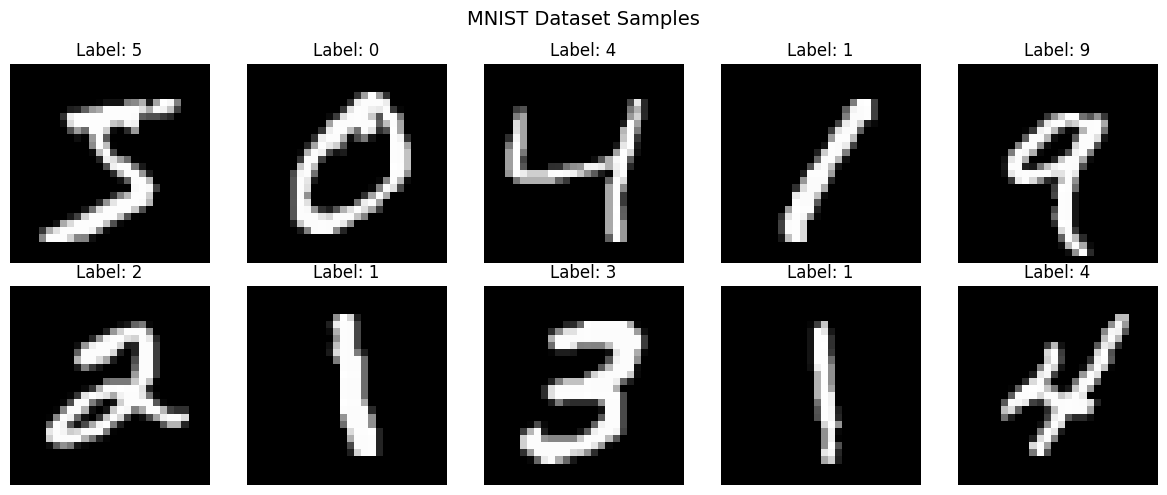

In [2]:
# 下载并加载 MNIST 数据集
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),  # 转为张量
    transforms.Normalize((0.1307,), (0.3081,))  # 标准化
])

train_dataset = datasets.MNIST(
    root='Week03/data', train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root='Week03/data', train=False, download=True, transform=transform
)
print(f"训练集: {len(train_dataset)} 张图片")
print(f"测试集: {len(test_dataset)} 张图片")

# 可视化一些样本
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = train_dataset[i]
    row, col = i // 5, i % 5
    axes[row, col].imshow(img.squeeze(), cmap='gray')
    axes[row, col].set_title(f'Label: {label}')
    axes[row, col].axis('off')
plt.suptitle('MNIST Dataset Samples', fontsize=14)
plt.tight_layout()
plt.savefig('images/cnn_day04_mnist_samples.png', dpi=150)
plt.show()

---

## 3. 训练 LeNet-5

完整的训练流程：
```
for each batch:
    1. 前向传播：图片 → CNN → 预测
    2. 计算损失：CrossEntropyLoss
    3. 反向传播：计算梯度
    4. 更新权重：optimizer.step()
```

In [3]:
# 创建数据加载器
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1000, shuffle=False
)

# 定义优化器和损失函数
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)
    
    return total_loss / len(loader), 100. * correct / total

def test(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in loader:
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    
    return total_loss / len(loader), 100. * correct / total

In [4]:
# 训练
print("开始训练 LeNet-5...")
print("="*60)

train_losses = []
test_losses = []
test_accs = []

epochs = 5
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc = test(model, test_loader, criterion)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs}: Train Loss={train_loss:.4f}, "
          f"Train Acc={train_acc:.2f}%, Test Loss={test_loss:.4f}, Test Acc={test_acc:.2f}%")

print("\n训练完成！")

开始训练 LeNet-5...


Epoch 1/5: Train Loss=0.2258, Train Acc=92.89%, Test Loss=0.0740, Test Acc=97.65%


Epoch 2/5: Train Loss=0.0666, Train Acc=97.92%, Test Loss=0.0454, Test Acc=98.60%


Epoch 3/5: Train Loss=0.0481, Train Acc=98.52%, Test Loss=0.0340, Test Acc=98.84%


Epoch 4/5: Train Loss=0.0370, Train Acc=98.83%, Test Loss=0.0369, Test Acc=98.84%


Epoch 5/5: Train Loss=0.0307, Train Acc=99.04%, Test Loss=0.0346, Test Acc=98.87%

训练完成！


---

## 4. 可视化训练结果

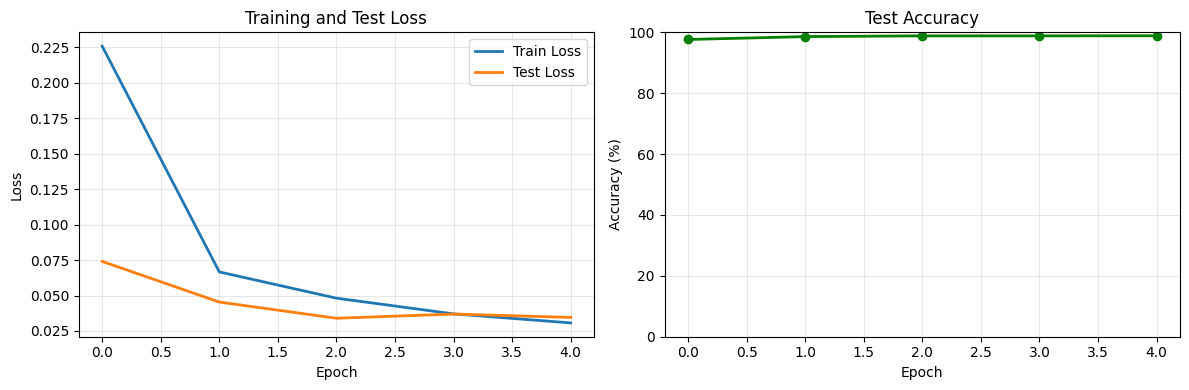


最终测试准确率: 98.87%
对于只有6万参数的网络来说，这是相当不错的成绩！


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(test_accs, 'g-', linewidth=2, marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.savefig('images/cnn_day04_training_results.png', dpi=150)
plt.show()

print(f"\n最终测试准确率: {test_accs[-1]:.2f}%")
print("对于只有6万参数的网络来说，这是相当不错的成绩！")

---

## 5. 可视化学到的卷积核

让我们看看第一个卷积层学到了什么。

第一个卷积层学到的 6 个卷积核 (5x5)：


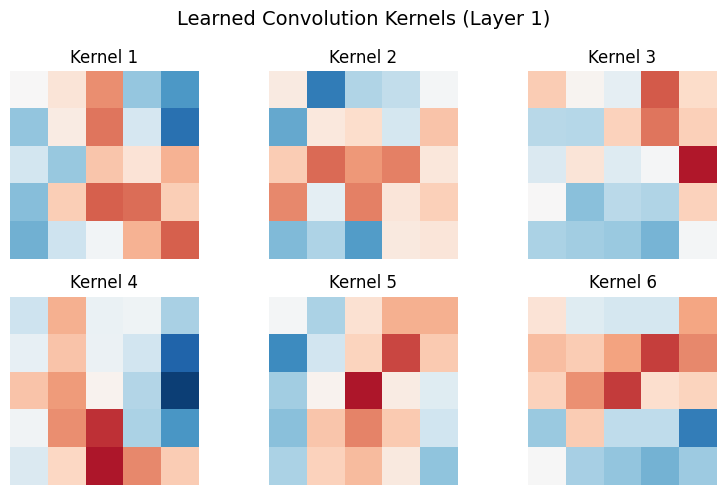


解读学到的卷积核：
  红色区域：对这种模式「兴奋」
  蓝色区域：对这种模式「抑制」
  不同的核检测不同的边缘方向或纹理


In [6]:
# 提取第一个卷积层的权重
conv1_weights = model.features[0].weight.data

print("第一个卷积层学到的 6 个卷积核 (5x5)：")
fig, axes = plt.subplots(2, 3, figsize=(8, 5))
for i in range(6):
    row, col = i // 3, i % 3
    ax = axes[row, col]
    kernel = conv1_weights[i, 0].numpy()
    im = ax.imshow(kernel, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    ax.set_title(f'Kernel {i+1}')
    ax.axis('off')
plt.suptitle('Learned Convolution Kernels (Layer 1)', fontsize=14)
plt.tight_layout()
plt.savefig('images/cnn_day04_learned_kernels.png', dpi=150)
plt.show()

print("\n解读学到的卷积核：")
print("  红色区域：对这种模式「兴奋」")
print("  蓝色区域：对这种模式「抑制」")
print("  不同的核检测不同的边缘方向或纹理")

---

## 今日总结

| 概念 | 直觉理解 |
|------|----------|
| LeNet-5 | 1998年的经典CNN，用于手写数字识别 |
| Conv + Pool 组合 | 特征提取 → 压缩 → 更抽象的特征 |
| MNIST | 6万张手写数字，深度学习最经典的数据集 |
| CrossEntropyLoss | 多分类任务的损失函数 |

**CNN 的分层特征学习**：
- **浅层 Conv1**：检测边缘、纹理
- **深层 Conv2**：检测更复杂的形状（如弧度、闭环）
- **FC 层**：综合所有特征，做出最终分类

**明日预告**：CNN 虽然强大，但层数增加后会遇到「梯度消失」问题。明天学习 **ResNet** 如何通过残差连接解决这个难题！